In [56]:
import pandas as pd
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [57]:
car=pd.read_csv('car_dataset.Csv')
car

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [28]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [29]:
car.isna().sum()

model    0
mpg      0
cyl      0
disp     0
hp       0
drat     0
wt       0
qsec     0
vs       0
am       0
gear     0
carb     0
dtype: int64

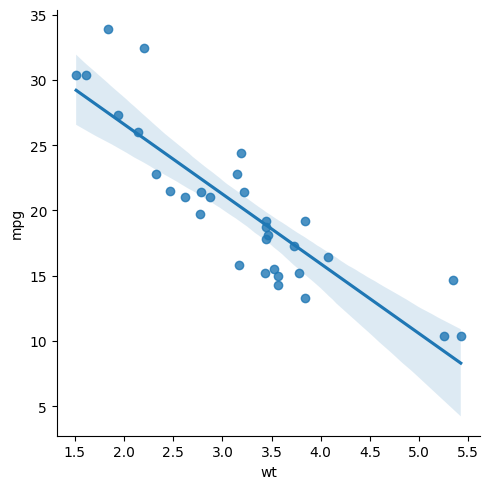

In [30]:
sns.lmplot(car,x='wt',y='mpg')

### DATA LINERALITY FAILED

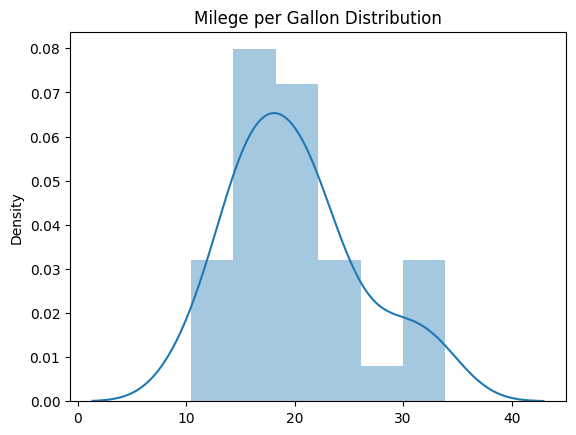

In [31]:
sns.distplot(x=car['mpg'])
plt.title('Milege per Gallon Distribution')
plt.show()

### IN THIS DATA , DATA NORMALITY FAILED (BELL shape curve)

In [32]:
c_matrix = car[['mpg','cyl','disp',	'hp','drat','wt','qsec','vs','am','gear','carb']].corr()
c_matrix

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


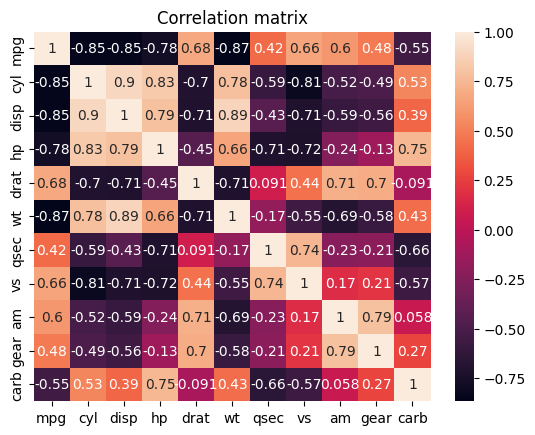

In [33]:
sns.heatmap(c_matrix, annot=True)
plt.title("Correlation matrix")
plt.show()

#### THERE IS NO NEED TO PREPARE DATA , BECAUSE All the input feautures are numeric

### Building Model

In [36]:
Linear_model = LinearRegression()

In [38]:
x = car[['hp','gear','wt','cyl']]
y = car['mpg']
Linear_model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
Linear_model.coef_

array([-0.02170211,  0.36259005, -3.02263457, -0.81259895])

In [40]:
Linear_model.intercept_

np.float64(36.68952971471994)

In [44]:
predicted_y=Linear_model.predict(x)
predicted_y

array([22.95776139, 22.18698958, 25.85868556, 20.79670377, 17.08077587,
       20.16466886, 15.1686856 , 23.90175893, 23.30649464, 20.1970736 ,
       20.1970736 , 15.06800553, 16.09570129, 15.94456956, 10.95874397,
       10.21578444, 10.1290409 , 26.80735871, 28.87942948, 27.93232243,
       24.97100505, 17.38151788, 17.63844182, 14.35257426, 15.85660887,
       27.60835687, 26.80875405, 28.22649948, 16.69057941, 21.45631903,
       13.94067569, 24.12103988])

### Model_Evalution

In [52]:
error= y - predicted_y
error

0    -1.957761
1    -1.186990
2    -3.058686
3     0.603296
4     1.619224
5    -2.064669
6    -0.868686
7     0.498241
8    -0.506495
9    -0.997074
10   -2.397074
11    1.331994
12    1.204299
13   -0.744570
14   -0.558744
15    0.184216
16    4.570959
17    5.592641
18    1.520571
19    5.967678
20   -3.471005
21   -1.881518
22   -2.438442
23   -1.052574
24    3.343391
25   -0.308357
26   -0.808754
27    2.173501
28   -0.890579
29   -1.756319
30    1.059324
31   -2.721040
Name: mpg, dtype: float64

In [58]:
car['error'] = error
car

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,error
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,-1.957761
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,-1.186990
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,-3.058686
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,0.603296
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,1.619224
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1,-2.064669
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4,-0.868686
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2,0.498241
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2,-0.506495
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4,-0.997074


### Model deployment

In [60]:
from pickle import dump

In [61]:
dump(obj=Linear_model, file=open(file="Linear_intelligence_prediction.pkl",
    mode='wb'))

In [62]:
from pickle import load

In [68]:
Linear_intelligence_prediction = load(file = open("Linear_intelligence_prediction.pkl",
    mode='rb'))
Linear_intelligence_prediction

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
